# Testing Data Retrieval and Database Building from WQP
Using WQP's webservice APIs

In [1]:
# %pip -q install pandas

In [2]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"
bbox = "-121.862622,38.018421,-121.027084,38.736405" #Example bounding box (for Sacramento county)

params = [
    ("bBox", bbox),
    ("dataProfile", "resultPhysChem"),
    ("providers", "NWIS"),
    ("providers", "STORET"),
    ("mimeType", "csv"),
    ("zip", "no"),
    ("startDateLo", "01-01-2011"),
    ("startDateHi", "12-31-2021"),
]

r = requests.get(url, params=params, timeout=180)
print("STATUS:", r.status_code)
print("URL:", r.url)
print("Warning:", r.headers.get("Warning"))

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
df.head()


STATUS: 200
URL: https://www.waterqualitydata.us/data/Result/search?bBox=-121.862622%2C38.018421%2C-121.027084%2C38.736405&dataProfile=resultPhysChem&providers=NWIS&providers=STORET&mimeType=csv&zip=no&startDateLo=01-01-2011&startDateHi=12-31-2021


/var/folders/z7/_7gxg0dx5j971t3x2y5zvc540000gn/T/ipykernel_21507/1459840369.py:25: DtypeWarning: Columns (12,14,15,17,19,20,21,24,27,28,34,37,38,41,43,45,47,48,49,50,59,61,62,73,74,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(r.text))


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LabSamplePreparationUrl,LastUpdated,ProviderName
0,USGS-CA,USGS California Water Science Center,nwisca.01.01907757,Sample-Routine,Water,Surface Water,2019-08-06,11:28:00,PST,NaN,...,"USGS-Organic Chemistry Research Lab, Sacrament...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWIS
1,USGS-CA,USGS California Water Science Center,nwisca.01.01907757,Sample-Routine,Water,Surface Water,2019-08-06,11:28:00,PST,NaN,...,"USGS-Organic Chemistry Research Lab, Sacrament...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWIS
2,USGS-CA,USGS California Water Science Center,nwisca.01.02000475,Sample-Routine,Water,Surface Water,2019-10-17,08:46:00,PDT,NaN,...,U.S. Geological Survey-Water Resources Discipline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWIS
3,USGS-CA,USGS California Water Science Center,nwisca.01.02000475,Sample-Routine,Water,Surface Water,2019-10-17,08:46:00,PDT,NaN,...,U.S. Geological Survey-Water Resources Discipline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWIS
4,USGS-CA,USGS California Water Science Center,nwisca.01.02000475,Sample-Routine,Water,Surface Water,2019-10-17,08:46:00,PDT,NaN,...,U.S. Geological Survey-Water Resources Discipline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NWIS


In [3]:
print ("Data shape (rows, columns):", df.shape)

Data shape (rows, columns): (467344, 81)


## Core Columns for Trend Analysis

### Time Axis (Mandatory)
- `ActivityStartDate`
- `ActivityStartTime/Time`
- `ActivityEndDate`
- `ActivityEndTime/Time`

### Location Axis (Mandatory)
- `MonitoringLocationIdentifier`

### Location Context
- `ActivityDepthHeightMeasure/MeasureValue`
- `ActivityMediaName`

### Measurement Axis (Mandatory)
- `CharacteristicName`
- `ResultMeasureValue`
- `ResultMeasure/MeasureUnitCode`

---

## Quality Control Columns
- `ResultStatusIdentifier`
- `MeasureQualifierCode`
- `DetectionQuantitationLimitMeasure/MeasureValue`
- `ResultDetectionConditionText`

---

## Optional but Useful Columns
- `ProjectIdentifier`
- `ResultAnalyticalMethod/MethodName`
- `DataProvider`
- `ActivityDepthHeightMeasure/MeasureUnitCode`


Other potential columns:
- `ResultSampleFractionText`
- `ResultStatusIdentifier`
- `ResultAnalyticalMethod/MethodIdentifier`
- `ResultAnalyticalMethod/MethodIdentifierContext`
- `ResultAnalyticalMethod/MethodName`

- `AnalysisStartDate`
- `LastUpdated`

In [4]:
# filter only necessary columns
columns_to_keep = [
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "ActivityEndDate",
    "ActivityEndTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

df_target = df[columns_to_keep]
print ("Data shape (rows, columns) after filtering columns:", df_target.shape)

Data shape (rows, columns) after filtering columns: (467344, 18)


In [5]:
# %pip install matplotlib

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

"""
For each characteristic in `characteristics`, plots:
    A) raw scatter over time
    B) monthly mean trend
    C) monthly boxplots (distribution by month)

Notes:
    - Drops rows with missing date/characteristic/value
    - Coerces date/value types
    - Optionally filters to accepted results
    - If multiple units exist, can pick the most common unit to avoid mixing
"""
def plot_wqp_characteristic_trends(
    df: pd.DataFrame,
    characteristics,
    date_col: str = "ActivityStartDate",
    char_col: str = "CharacteristicName",
    value_col: str = "ResultMeasureValue",
    unit_col: str = "ResultMeasure/MeasureUnitCode",
    only_accepted: bool = False,
    status_col: str = "ResultStatusIdentifier",
    choose_unit: str = "most_common",   # "most_common" or a specific unit string
    showfliers: bool = False,
    point_size: int = 8
):
    
    # Normalize characteristics input
    if isinstance(characteristics, str):
        characteristics = [characteristics]

    data = df.copy()

    # Basic cleaning
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data[char_col].nunique())

    for char in characteristics:
        dchar = data[data[char_col] == char].copy()

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after filtering).")
            continue

        # Unit handling
        unit = None
        if unit_col in dchar.columns:
            if choose_unit == "most_common":
                unit = dchar[unit_col].dropna().value_counts().index[0] if dchar[unit_col].notna().any() else None
                if unit is not None:
                    dchar = dchar[dchar[unit_col] == unit]
            else: 
                unit = choose_unit
                dchar = dchar[dchar[unit_col] == unit]

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after unit filter).")
            continue

        print("Plotting characteristic:", char, "| unit:", unit)

        # ---- Plot A: raw time series (scatter) ----
        plt.figure(figsize=(4, 3))
        plt.scatter(dchar[date_col], dchar[value_col], s=point_size)
        plt.xlabel(date_col)
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Raw results over time: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot B: monthly mean trend ----
        monthly = (
            dchar.set_index(date_col)[value_col]
                .resample("MS")
                .mean()
                .dropna()
        )

        plt.figure(figsize=(4, 3))
        plt.plot(monthly.index, monthly.values)
        plt.xlabel("Month")
        plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly mean trend: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot C: monthly boxplots ----
        dchar["Month"] = dchar[date_col].dt.month
        months = list(range(1, 13))

        box_data = [
            dchar.loc[dchar["Month"] == m, value_col].dropna().values
            for m in months
        ]

        plt.figure(figsize=(4, 3))
        plt.boxplot(box_data, tick_labels=months, showfliers=showfliers)
        plt.xlabel("Month")
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly distribution: {char}")
        plt.tight_layout()
        plt.show()


num rows after cleaning: 294016
unique characteristics: 750
Skipping 'Temperature, sample' (no rows after filtering).
Plotting characteristic: Chloride | unit: mg/L


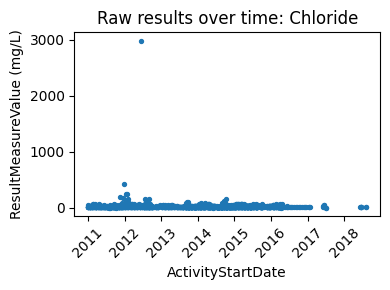

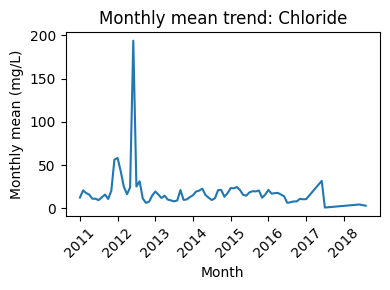

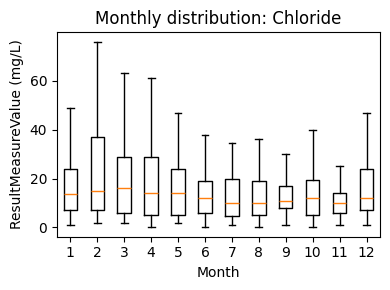

Plotting characteristic: Specific conductance | unit: uS/cm


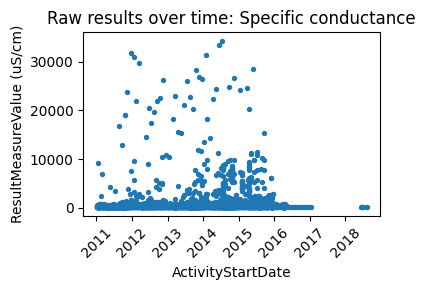

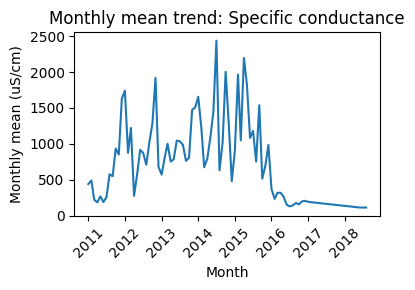

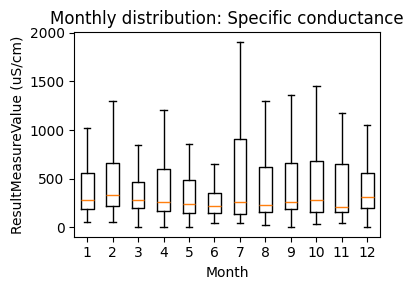

Skipping 'Flow' (no rows after filtering).
Plotting characteristic: Organic carbon | unit: mg/l


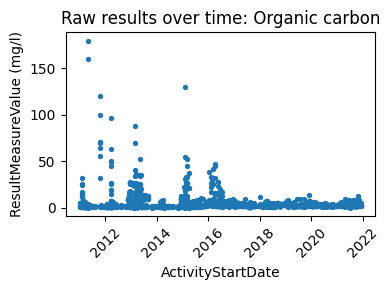

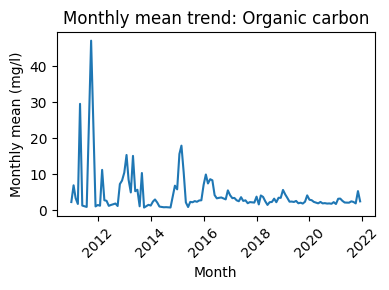

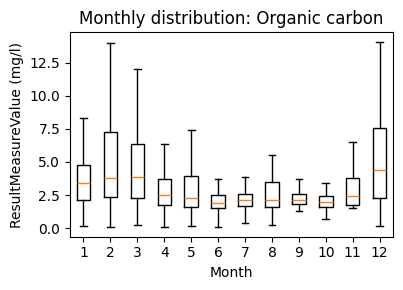

Plotting characteristic: pH | unit: std units


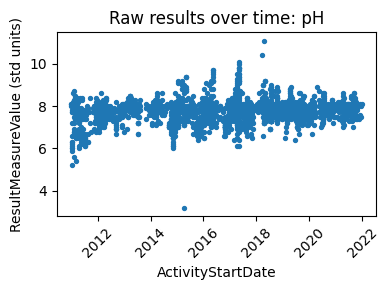

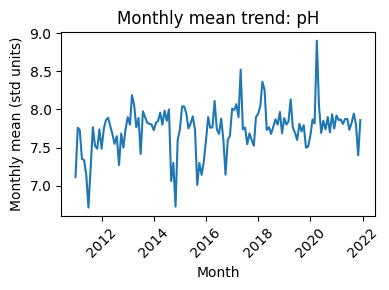

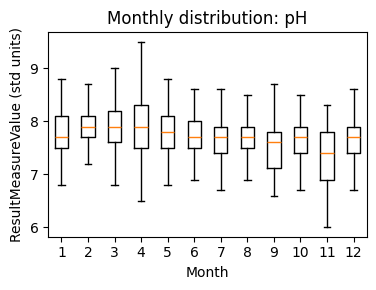

Plotting characteristic: Alkalinity, total | unit: mg/L


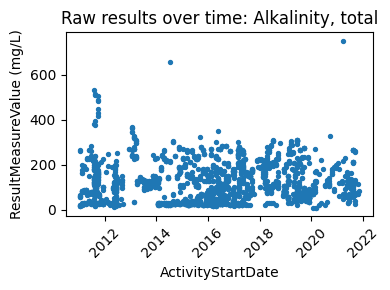

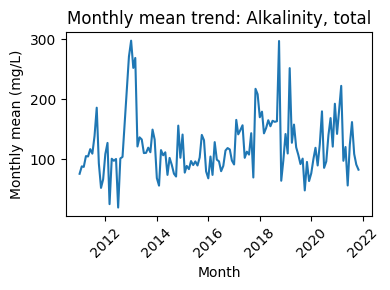

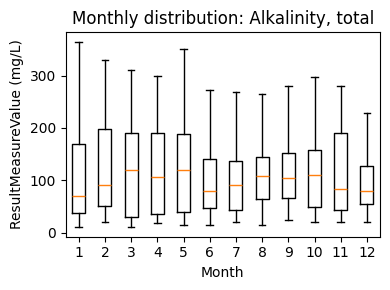

Plotting characteristic: Depth, Secchi disk depth | unit: m


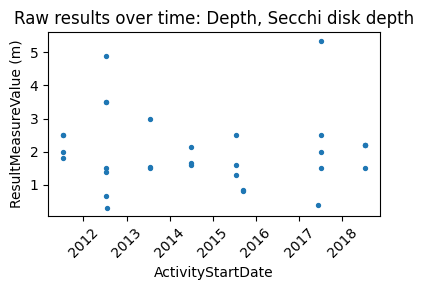

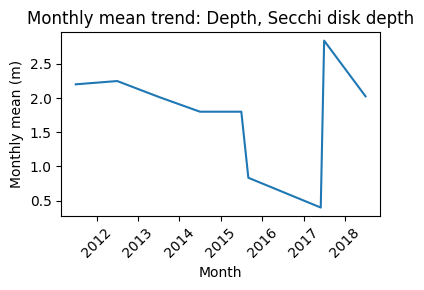

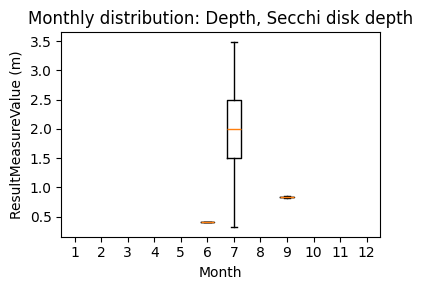

Plotting characteristic: Oxygen | unit: mg/L


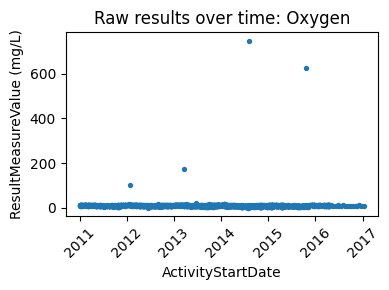

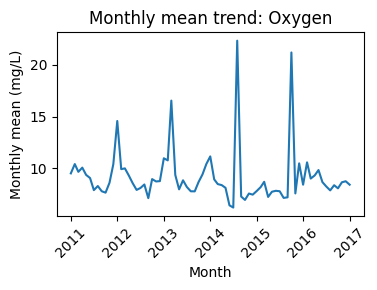

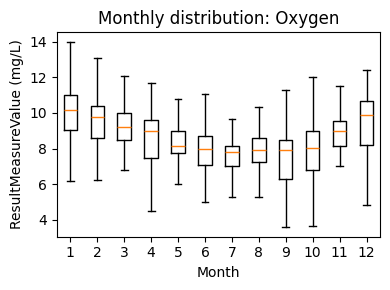

Plotting characteristic: Total dissolved solids | unit: mg/L


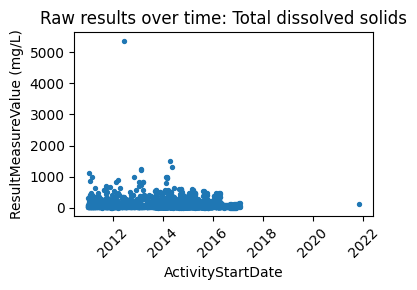

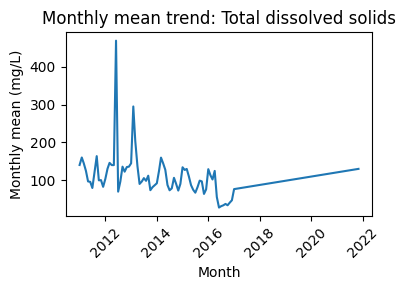

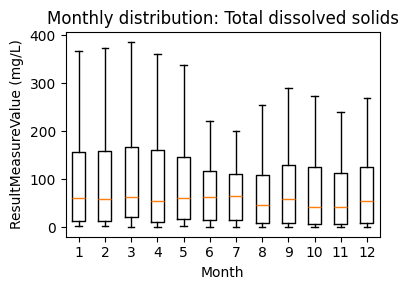

Plotting characteristic: Nitrogen | unit: mg/l


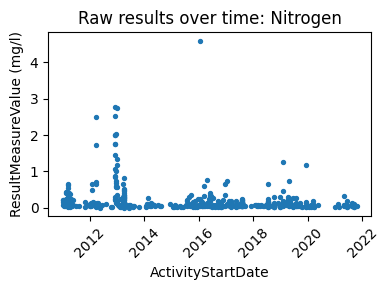

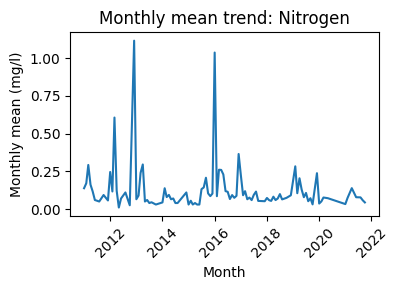

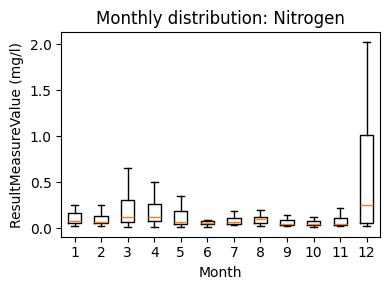

Plotting characteristic: Phosphorus | unit: mg/l as P


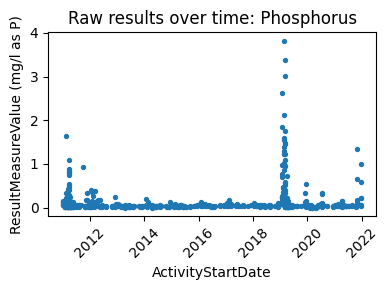

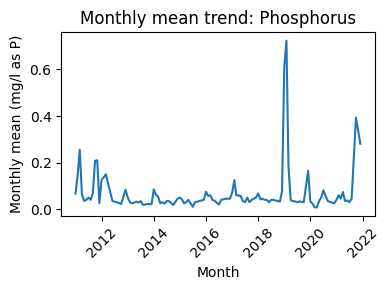

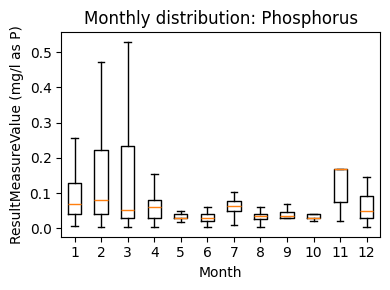

Plotting characteristic: Chlorophyll a | unit: ug/l


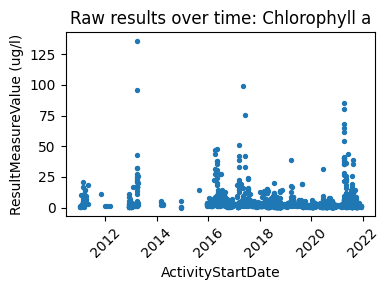

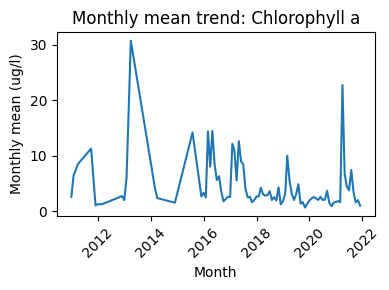

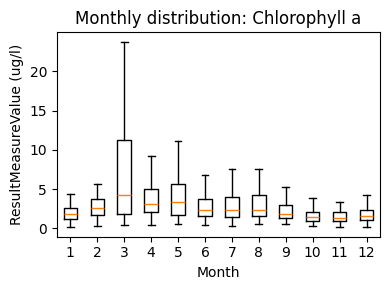

Skipping 'Reservoir volume' (no rows after filtering).
Plotting characteristic: Total suspended solids | unit: mg/l


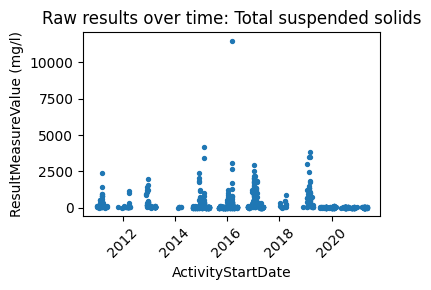

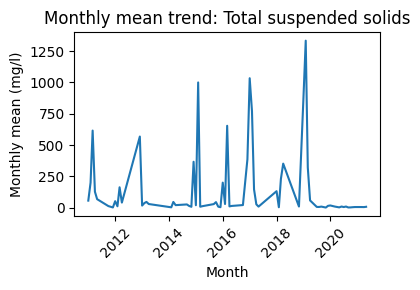

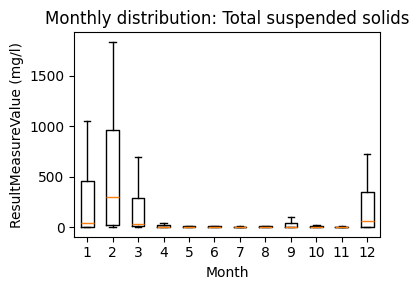

Plotting characteristic: Escherichia coli | unit: MPN/100mL


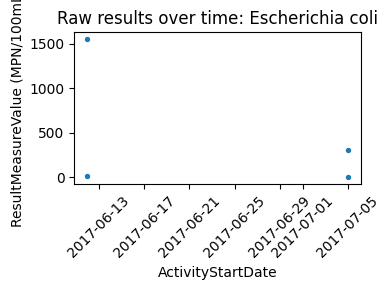

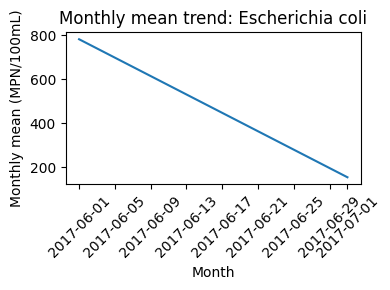

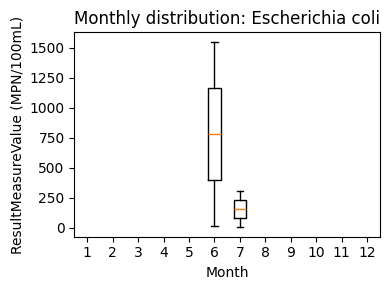

Skipping 'Hardness, magnesium' (no rows after filtering).
Plotting characteristic: Orthophosphate | unit: mg/l asPO4


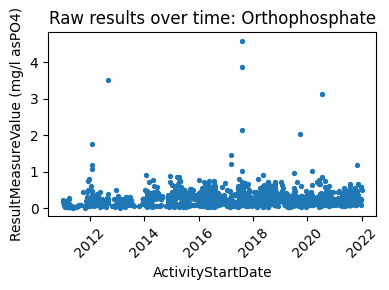

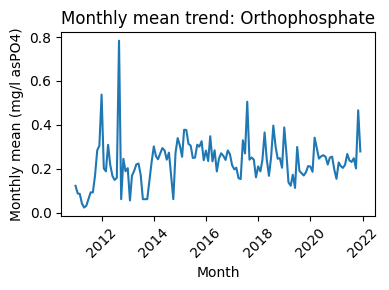

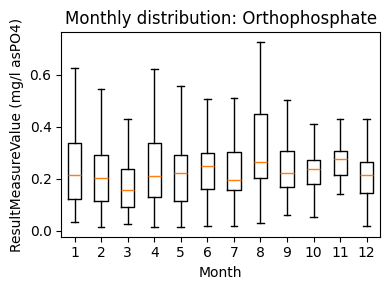

Skipping 'Precipitation' (no rows after filtering).
Plotting characteristic: Sulfate | unit: mg/L


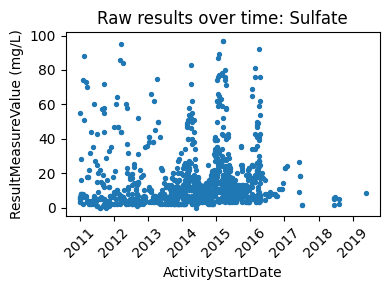

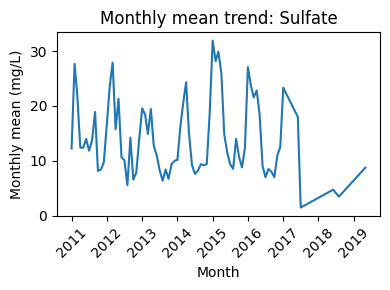

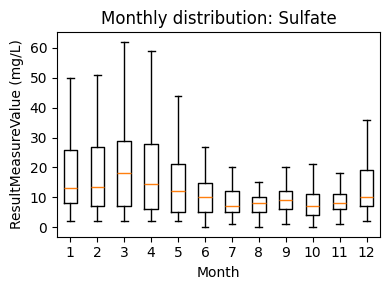

Plotting characteristic: Inorganic nitrogen (nitrate and nitrite) ***retired***use Nitrate + Nitrite | unit: mg/L


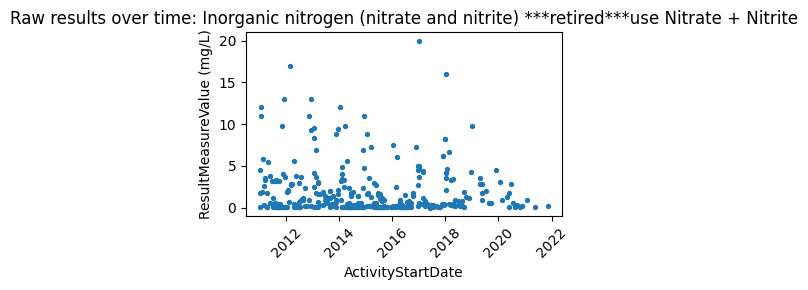

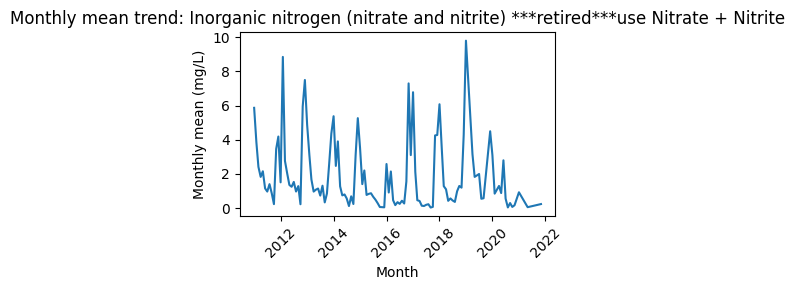

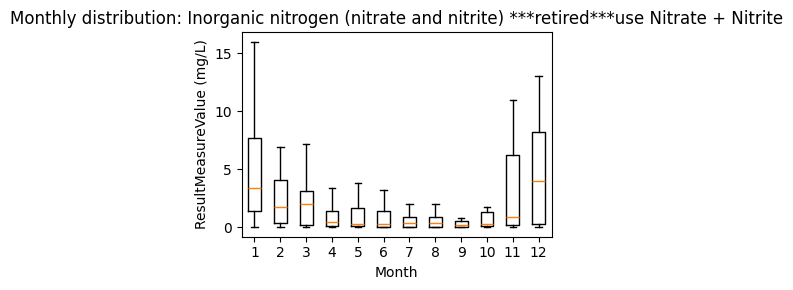

Plotting characteristic: Pheophytin a | unit: ug/l


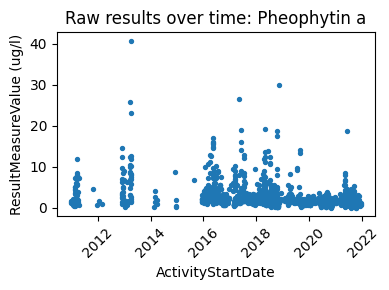

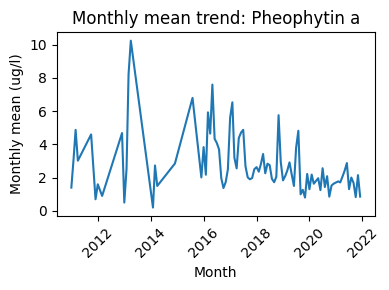

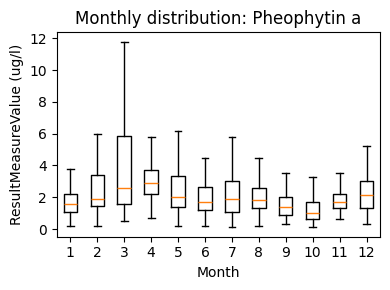

Plotting characteristic: Nitrate | unit: mg/l as N


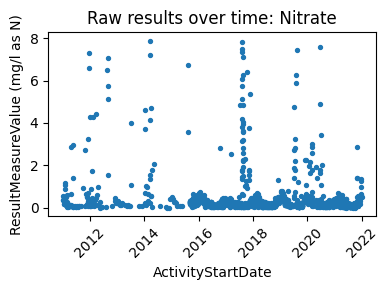

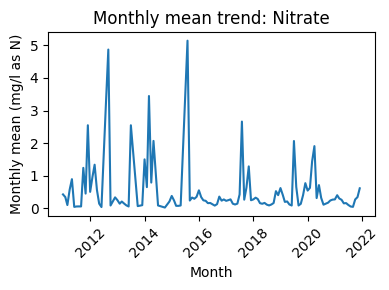

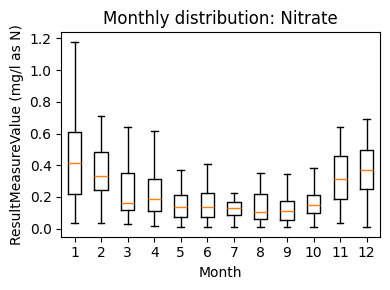

Plotting characteristic: Depth | unit: ft


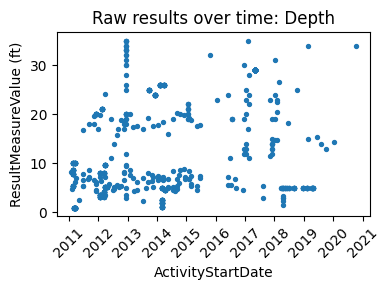

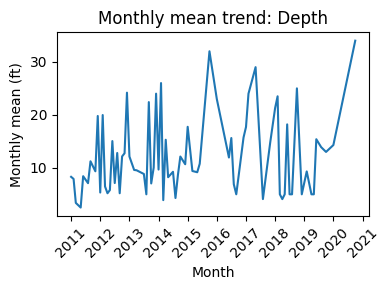

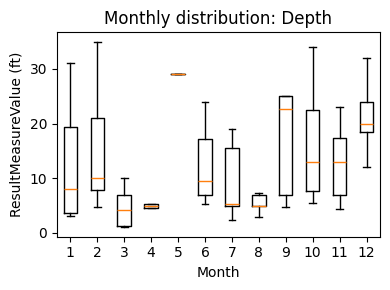

Plotting characteristic: Total volatile solids | unit: %


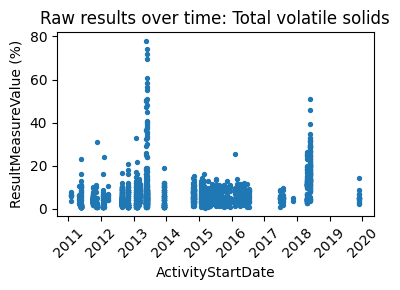

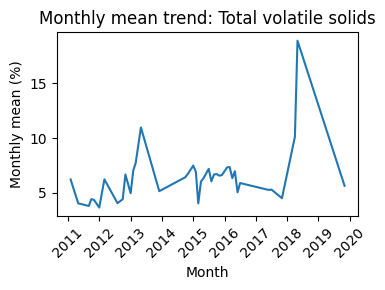

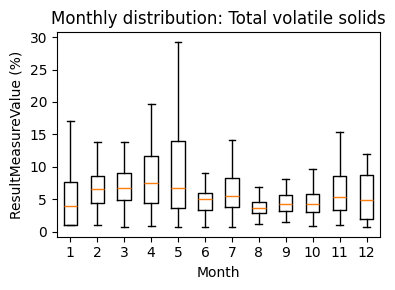

Plotting characteristic: Iron | unit: mg/L


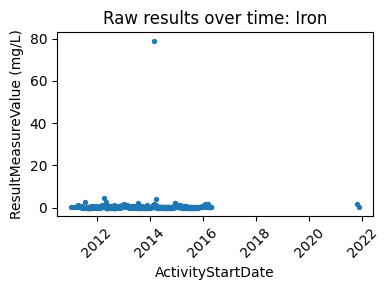

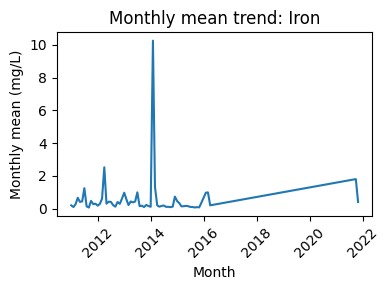

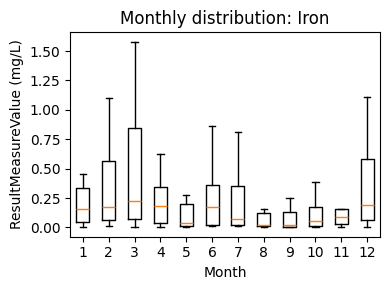

Plotting characteristic: Ammonia-nitrogen | unit: mg N/l******


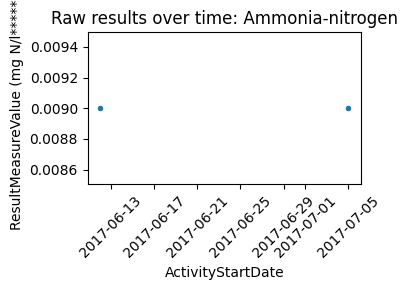

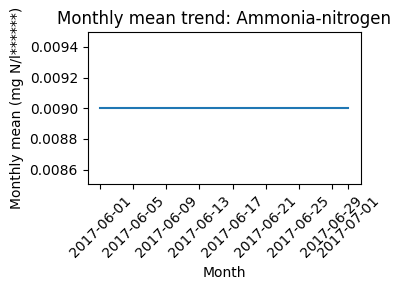

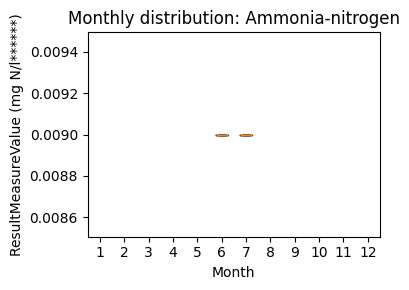

Plotting characteristic: Nitrite | unit: mg/l as N


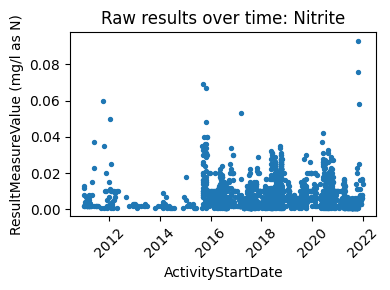

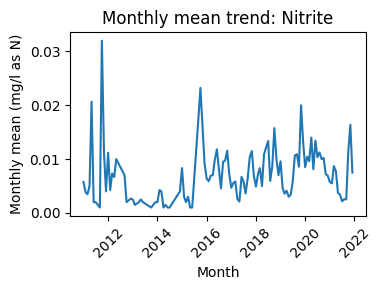

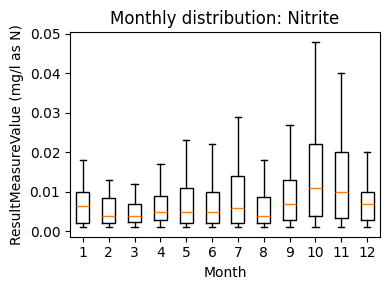

In [7]:
characteristics = [
    "Temperature, sample",
    "Chloride",
    "Specific conductance",
    "Flow",
    "Organic carbon",
    "pH",
    "Alkalinity, total",
    "Depth, Secchi disk depth",
    "Oxygen",
    "Total dissolved solids",
    "Nitrogen",
    "Phosphorus",
    "Chlorophyll a",
    "Reservoir volume",
    "Total suspended solids",
    "Escherichia coli",
    "Hardness, magnesium",
    "Orthophosphate",
    "Precipitation",
    "Sulfate",
    "Inorganic nitrogen (nitrate and nitrite) ***retired***use Nitrate + Nitrite",
    "Pheophytin a",
    "Nitrate",
    "Depth",
    "Total volatile solids",
    "Iron",
    "Ammonia-nitrogen",
    "Nitrite"
]
plot_wqp_characteristic_trends(df_target, characteristics)


In [8]:
import pandas as pd
import numpy as np

'''
Classify selected characteristics based on their data coverage and gaps.
Criteria:
- Good: >75% monthly coverage and no gaps longer than 2 months
- Okay: >40% coverage but not meeting Good criteria
- Bad: <=40% coverage or no data
'''

def classify_selected_characteristics(df):

    df["ActivityStartDate"] = pd.to_datetime(df["ActivityStartDate"])
    df = df[df["CharacteristicName"].isin(characteristics)]

    results = []

    for char, g in df.groupby("CharacteristicName"):

        g = g.sort_values("ActivityStartDate")
        g["month"] = g["ActivityStartDate"].dt.to_period("M")

        counts = g.groupby("month").size()

        start = counts.index.min()
        end = counts.index.max()

        full_range = pd.period_range(start=start, end=end, freq="M")
        counts = counts.reindex(full_range, fill_value=0)

        months_with_data = (counts > 0).sum()
        total_months = len(counts)
        coverage = months_with_data / total_months

        # longest gap
        longest_gap = 0
        gap = 0
        for v in counts:
            if v == 0:
                gap += 1
                longest_gap = max(longest_gap, gap)
            else:
                gap = 0

        obs = len(g)

        if obs == 0:
            label = "Bad (no data)"
        elif coverage > 0.75 and longest_gap <= 2:
            label = "Good"
        elif coverage > 0.40:
            label = "Okay"
        else:
            label = "Bad"

        results.append({
            "Characteristic": char,
            "Observations": obs,
            "Coverage": round(coverage,2),
            "LongestGapMonths": longest_gap,
            "Label": label
        })

    return pd.DataFrame(results)


summary = classify_selected_characteristics(df)
summary.sort_values("Label")

,Characteristic,Observations,Coverage,LongestGapMonths,Label
5,"Depth, Secchi disk depth",31,0.11,20,Bad
6,Escherichia coli,63,0.16,24,Bad
21,Total volatile solids,1856,0.38,17,Bad
0,"Alkalinity, total",3297,0.99,1,Good
20,Total suspended solids,1518,0.98,1,Good
19,Total dissolved solids,3313,0.93,1,Good
18,Sulfate,2434,0.95,1,Good
17,Specific conductance,5800,1.00,0,Good
16,Phosphorus,1090,0.92,1,Good
14,Oxygen,5471,1.00,0,Good
